# 🟢(Loan Approval Dataset)



#  **🛑 (Data Understanding & Visualization)**



#  استدعاء المكتبات الأساسية

In [254]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print("Libraries imported successfully")

Libraries imported successfully


# قراءة البيانات واستكشافها

In [255]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/altruistdelhite04/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv')

# Show first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# معرفة حجم البيانات 

In [256]:
# Dataset Shape
# Shows number of rows and columns.

print("Rows and Columns:", df.shape)

Rows and Columns: (614, 13)


# اسماء الاعمدة 

In [257]:
# Features
# Displays all dataset features.

print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


# انواع البيانات 

In [258]:
# Data Information
# Shows data types and missing values.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# احصائيات رقمية 

In [259]:
# Statistical Summary
# Displays mean, min, max, and other statistics.

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# فحص القيم الناقصة 

In [260]:
# Missing Values
# Checks missing data in each column.

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

#  الرسم البياني الأول
# (المتغير المستهدف - Loan Status)

هنا سنرى كم شخص تم قبول قرضه (Y)

وكم شخص تم رفضه (N).

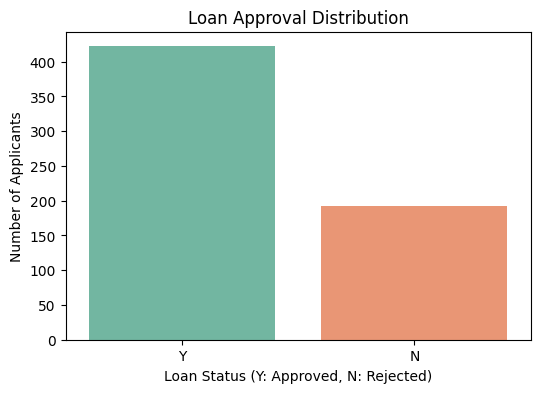

In [261]:

# Loan Status Distribution
# Shows approved vs rejected loans.

plt.figure(figsize=(6, 4)) # تحديد الحجم
sns.countplot(x='Loan_Status', data=df, palette='Set2') # إضافة ألوان متناسقة
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (Y: Approved, N: Rejected)") # تسمية محور X
plt.ylabel("Number of Applicants") # تسمية محور Y
plt.show()

# الرسم البياني الثاني

# Education vs Loan Status (تأثير مستوى التعليم)

يوضح هذا الرسم المقارنة بين المتقدمين الخريجين وغير الخريجين ونسبة قبول أو رفض القروض لكل فئة.

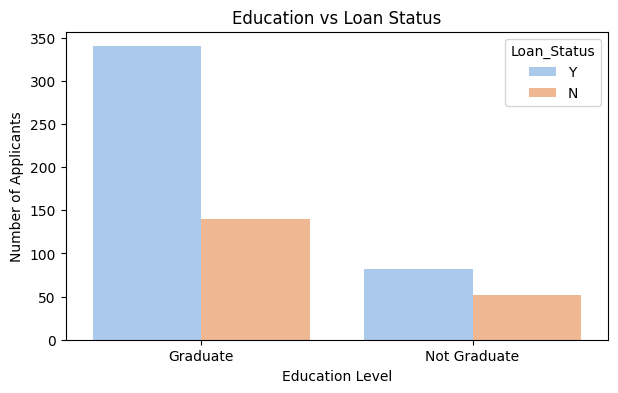

In [262]:

# Education Effect
# Compares education level with loan approval.

plt.figure(figsize=(7, 4)) # تحديد الحجم
sns.countplot(x='Education', hue='Loan_Status', data=df, palette='pastel')
plt.title("Education vs Loan Status")
plt.xlabel("Education Level") # تسمية محور X
plt.ylabel("Number of Applicants") # تسمية محور Y
plt.show()

# الرسم البياني الثالث

# Credit History vs Loan Status (تأثير التاريخ الائتماني)

نستعرض هنا مدى تأثير وجود سجل ائتماني سابق للعميل (Credit History) على قرار البنك بالموافقة أو الرفض.

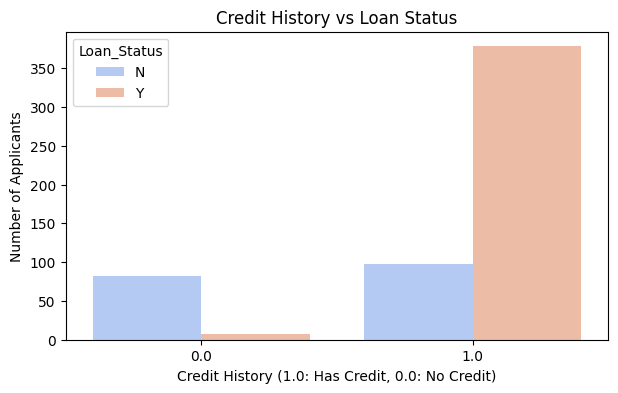

In [263]:
# Credit History Impact
# Shows how credit history affects approval.

plt.figure(figsize=(7, 4)) # تحديد الحجم
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='coolwarm')
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History (1.0: Has Credit, 0.0: No Credit)") # تسمية محور X
plt.ylabel("Number of Applicants") # تسمية محور Y
plt.show()

# **🛑 (Data Preprocessing)**



# Check Missing Values

In [264]:

print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


=== Missing Values ===
                  Missing Count  Percentage %
Gender                       13          2.12
Married                       3          0.49
Dependents                   15          2.44
Self_Employed                32          5.21
LoanAmount                   22          3.58
Loan_Amount_Term             14          2.28
Credit_History               50          8.14


# Handle Missing Values

In [265]:
# Categorical columns → fill with Mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns → fill with Median
numeric_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print('After Handling - Missing Values:')
print(df.isnull().sum())


After Handling - Missing Values:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


#  Label Encoding

In [266]:
le = LabelEncoder()
cols_to_encode = ['Gender', 'Married', 'Dependents', 'Education',
                  'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cols_to_encode:
    df[col] = le.fit_transform(df[col])

print('After Encoding:')
print(df.head())


After Encoding:
    Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0  LP001002       1        0           0          0              0   
1  LP001003       1        1           1          0              0   
2  LP001005       1        1           0          0              1   
3  LP001006       1        1           0          1              0   
4  LP001008       1        0           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1             1.0              0        

# Define X and y

In [267]:
df = df.drop(columns=['Loan_ID'])

X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (614, 11)
y shape: (614,)


# Train / Test Split

In [268]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Testing set:  {X_test.shape}')


Training set: (491, 11)
Testing set:  (123, 11)


# Model SMOTHE
DATA IS IMBALANCED

In [269]:
from imblearn.over_sampling import SMOTE

# 1. إنشاء أداة SMOTE
smote = SMOTE(random_state=42)

# 2. موازنة بيانات التدريب فقط (توليد عينات جديدة للفئة الأقل)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# الآن أصبح لديكِ بيانات متوازنة تماماً وجاهزة لتدريب أي موديل!

# Loan statue after SMOTHE

Class counts after SMOTE:
Loan_Status
1    337
0    337
Name: count, dtype: int64


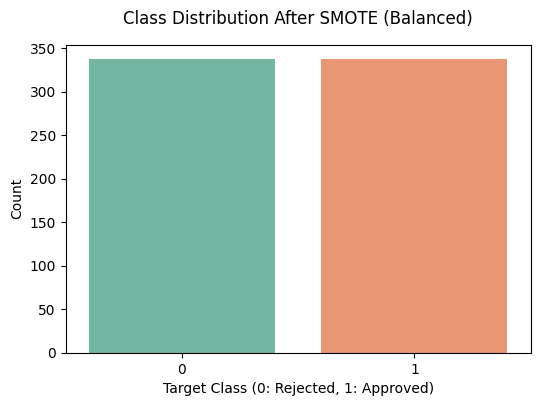

In [289]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert SMOTE target array to a pandas Series for plotting
y_train_balanced_df = pd.Series(y_train_balanced)

print("Class counts after SMOTE:")
print(y_train_balanced_df.value_counts())

# Class distribution plot "After SMOTE"
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_balanced_df, palette='Set2')

plt.title('Class Distribution After SMOTE (Balanced)', fontsize=12, pad=15)
plt.xlabel('Target Class (0: Rejected, 1: Approved)')
plt.ylabel('Count')
plt.show()

# Feature Scaling

In [271]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled  = scaler.transform(X_test)

print('✅ Data is ready for modeling!')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')


✅ Data is ready for modeling!
X_train_scaled shape: (674, 11)
X_test_scaled shape:  (123, 11)


# 🛑 Model Implementation


In [272]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Libraries imported successfully ✅")


Libraries imported successfully ✅


## Model 1: Logistic Regression
يحسب احتمال قبول القرض أو رفضه.


In [273]:
# استدعاء النموذج الأول وتدريبه
# Build and Train Model 1: Logistic Regression
model1 = LogisticRegression(random_state=42, max_iter=1000)
model1.fit(X_train_scaled, y_train_balanced)

# عمل التنبؤات
# Predictions
y_pred1 = model1.predict(X_test_scaled)
print("Model 1 - Sample predictions:", y_pred1[:10])


Model 1 - Sample predictions: [0 1 1 1 1 1 1 1 1 1]


## Model 2: Random Forest
يبني 100 شجرة قرار ويختار النتيجة بالتصويت.


In [274]:
# استدعاء النموذج الثاني وتدريبه
# Build and Train Model 2: Random Forest
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train_scaled, y_train_balanced)

# عمل التنبؤات
# Predictions
y_pred2 = model2.predict(X_test_scaled)
print("Model 2 - Sample predictions:", y_pred2[:10])


Model 2 - Sample predictions: [0 1 1 1 1 0 1 1 0 1]


# Model3: CatBoost 


In [275]:
!pip install catboost

In [276]:
from catboost import CatBoostClassifier

# 1. بناء وتدريب موديل CatBoost
# اخترنا iterations=500 لأن حجم البيانات صغير لتفادي الـ Overfitting
model_cat = CatBoostClassifier(iterations=500, random_state=42, verbose=0)
model_cat.fit(X_train_scaled, y_train_balanced)

# 2. عمل التنبؤات باستخدام بيانات الاختبار
y_pred_cat = model_cat.predict(X_test_scaled)

print("Model 3 (CatBoost) - Sample predictions:", y_pred_cat[:10])


Model 3 (CatBoost) - Sample predictions: [0 1 1 0 1 0 1 1 0 1]


# Evaluation



In [281]:
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

import the library

* •  Accuracy — نسبة التوقعات الصحيحة
 * • Classification Report — Precision, Recall, F1 لكل class
 * • Confusion Matrix — تشوفين وين يغلط الموديل* 

# The first model

Model 1 - Accuracy: 0.8293

Model 1 - Classification Report:
              precision    recall  f1-score   support

    Rejected       0.76      0.66      0.70        38
    Approved       0.86      0.91      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.78      0.79       123
weighted avg       0.83      0.83      0.83       123



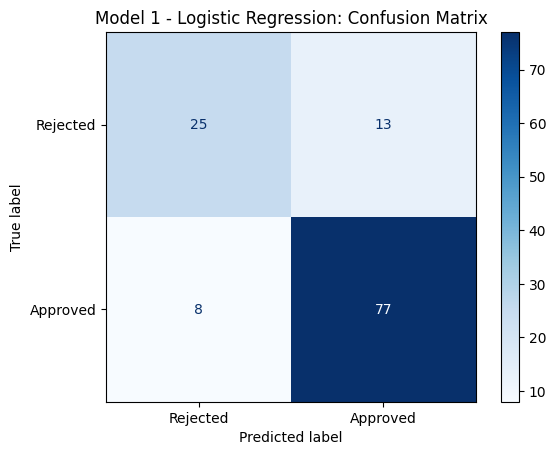

In [282]:
accuracy1 = accuracy_score(y_test, y_pred1)
print(f"Model 1 - Accuracy: {accuracy1:.4f}")

# تقرير مفصّل (Precision, Recall, F1)
print("\nModel 1 - Classification Report:")
print(classification_report(y_test, y_pred1, target_names=["Rejected", "Approved"]))

# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["Rejected", "Approved"])
disp1.plot(cmap="Blues")
plt.title("Model 1 - Logistic Regression: Confusion Matrix")
plt.show()

the model is week on rejected 0.58

# The seconed model

Model 2 - Accuracy: 0.8049

Model 2 - Classification Report:
              precision    recall  f1-score   support

    Rejected       0.69      0.66      0.68        38
    Approved       0.85      0.87      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.77       123
weighted avg       0.80      0.80      0.80       123



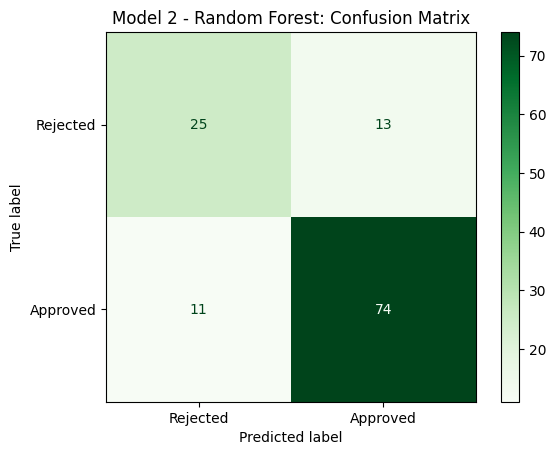

In [283]:
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Model 2 - Accuracy: {accuracy2:.4f}")

# تقرير مفصّل
print("\nModel 2 - Classification Report:")
print(classification_report(y_test, y_pred2, target_names=["Rejected", "Approved"]))

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Rejected", "Approved"])
disp2.plot(cmap="Greens")
plt.title("Model 2 - Random Forest: Confusion Matrix")
plt.show()

# The third model

Model 3 - CatBoost Accuracy: 80.49%

Model 3 - CatBoost: Classification Report:
              precision    recall  f1-score   support

    Rejected       0.71      0.63      0.67        38
    Approved       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123



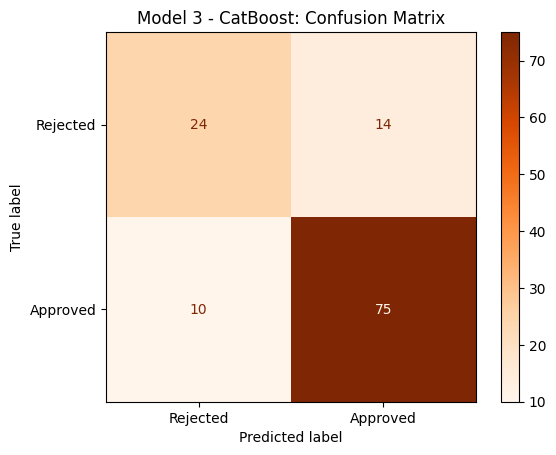

In [284]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. حساب الدقة الإجمالية وطباعتها بشكل مستقل ومميز
acc_cat = accuracy_score(y_test, y_pred_cat)
print(f"Model 3 - CatBoost Accuracy: {acc_cat*100:.2f}%")

# 2. التقرير المفصّل لموديل كاتبوست
print("\nModel 3 - CatBoost: Classification Report:")
print(classification_report(y_test, y_pred_cat, target_names=["Rejected", "Approved"]))

# 3. Confusion Matrix لموديل كاتبوست
cm_cat = confusion_matrix(y_test, y_pred_cat)
disp_cat = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=["Rejected", "Approved"])

# رسم المصفوفة باللون البرتقالي
disp_cat.plot(cmap="Oranges")
plt.title("Model 3 - CatBoost: Confusion Matrix")
plt.show()

# Comparison between the first and second model.

============ Final Model Comparison Table ============
              Model Accuracy F1-Score (Rejected)  False Positives (FP)
Logistic Regression   82.93%                0.70                    13
      Random Forest   80.49%                0.68                    13
           CatBoost   80.49%                0.67                    14


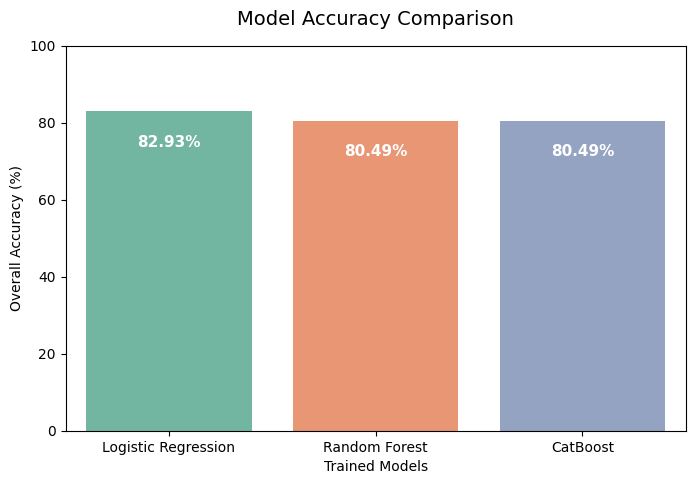

In [287]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# 1. Calculate metrics for each model based on corrected scaling predictions
results_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'CatBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred_cat)
    ],
    'F1-Score (Rejected)': [
        f1_score(y_test, y_pred1, pos_label=0), 
        f1_score(y_test, y_pred2, pos_label=0),
        f1_score(y_test, y_pred_cat, pos_label=0)
    ],
    'False Positives (FP)': [
        confusion_matrix(y_test, y_pred1)[0, 1],
        confusion_matrix(y_test, y_pred2)[0, 1],
        confusion_matrix(y_test, y_pred_cat)[0, 1]
    ]
}

# 2. Convert results to DataFrame for clean printing
df_compare = pd.DataFrame(results_data)

print("============ Final Model Comparison Table ============")
df_printed = df_compare.copy()
df_printed['Accuracy'] = df_printed['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_printed['F1-Score (Rejected)'] = df_printed['F1-Score (Rejected)'].apply(lambda x: f"{x:.2f}")
print(df_printed.to_string(index=False))
print("======================================================")

# 3. Plot Model Accuracy Comparison (Bar Chart)
plt.figure(figsize=(8, 5))
df_compare['Accuracy (%)'] = df_compare['Accuracy'] * 100

ax = sns.barplot(x='Model', y='Accuracy (%)', data=df_compare, palette='Set2')

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() - 8), 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.title('Model Accuracy Comparison', fontsize=14, pad=15)
plt.ylim(0, 100) 
plt.ylabel('Overall Accuracy (%)')
plt.xlabel('Trained Models')
plt.show()